# 산포통계

In [1]:
import numpy as np
from scipy import stats
import pandas as pd

#### 분산 계산

In [2]:
x = [1, 2, 3, 4, 5]
print(np.var(x, ddof = 1)) # 분모 = n - 1 ( 5 - 1), 표본
print(np.array(x).var()) # 분모 = n
# 분모 = n , 자유도(ddof) 0:모분산인경우, 표본분산
print(pd.Series(x).var(ddof = 0)) 

2.5
2.0
2.0


In [ ]:
x = [1, 2, 3, 4, 5]
print(pd.Series(x).var(ddof = 1)) 
# x에 대한 표본의 분산을 알아볼 것이다.
# 여기에서 보면 알 수 있듯이 보통 list는 열벡터로 들어감.

2.5


#### 표준편차 계산

In [ ]:
x = [1, 2, 3, 4, 5]
print(np.std(x, ddof = 1))
print(np.array(x).std(ddof = 0))
print(pd.Series(x).std(ddof = 1)) # standard deviation을 구한다.

1.5811388300841898
1.4142135623730951
1.5811388300841898


In [11]:
print(pd.Series(x).std(ddof = 0))

1.4142135623730951


#### 변동계수의 필요성
- 분산과 표준편차 모두 값의 스케일에 크게 영향을 받아 상대적인 산포를 보여주는데 부작합함.
- 변동 계수 = 표준편차 / 평균

In [4]:
x1 = np.array([1, 2, 3, 4, 5])
x2 = x1 * 10

print(np.std(x1, ddof = 1))
print(np.std(x2, ddof = 1))

1.5811388300841898
15.811388300841896


In [5]:
print(stats.variation(x1)) # 변동 계수
print(stats.variation(x2))

0.47140452079103173
0.4714045207910317


In [6]:
print(np.std(x1, ddof = 1) / np.mean(x1))
print(np.std(x2, ddof = 1) / np.mean(x2))

0.5270462766947299
0.5270462766947299


#### 스케일링
- 둘 이상의 변수의 값을 상대적으로 비교할 때 사용

In [7]:
import numpy as np
import pandas as pd

In [3]:
x1 = np.array([1, 2, 3, 4, 5])
x2 = x1 * 10

In [9]:
x1

array([1, 2, 3, 4, 5])

In [10]:
x2

array([10, 20, 30, 40, 50])

In [4]:
# Standard Scaling
z1 = (x1 - x1.mean()) / x1.std()
z2 = (x2 - x2.mean()) / x2.std()

print(z1)
print(z2)

[-1.41421356 -0.70710678  0.          0.70710678  1.41421356]
[-1.41421356 -0.70710678  0.          0.70710678  1.41421356]


In [5]:
# Min-max Scaling
z1 = (x1 - x1.min()) / (x1.max() - x1.min())
z2 = (x2 - x2.min()) / (x2.max() - x2.min())

print(z1)
print(z2)

[0.   0.25 0.5  0.75 1.  ]
[0.   0.25 0.5  0.75 1.  ]


In [16]:
# sklearn을 이용한 스케일링을 위한 데이터 준비
X = pd.DataFrame({"X1":[1, 2, 3, 4, 5],
    "X2": [10, 20, 30, 40, 50]})

X
# 반복: pandas의 dataframe은 열벡터로 들어간다. 

,X1,X2
0,1,10
1,2,20
2,3,30
3,4,40
4,5,50


- 라이브러리 설치
    - ```uv add scikit-learn```

In [ ]:
# scikit learn 의 MinMaxScaler 적용
# 0 ~ 1 데이터 스크케일링함
from sklearn.preprocessing import MinMaxScaler # sklearn의 preprocessing 안에 있는 걸 부름

scaler = MinMaxScaler() # 인스턴스화
Z = scaler.fit_transform(X) # fit_transform => ndarray

# fit_transform은 fit와 transform을 동시에 수행하는 명령어.
# fit : 필요한 통계값 구함. transform : 구한 통계값을 바탕으로 scaling 수행.
# ndarray는 numpy에서 사용하는 숫자열을 의미. 열의 숫자 내용 값만을 의미함.
# 이것은 그룹 정보 즉, dataframe의 행인 몇 번째인지, 열의 누구에 대한 것인지의 정보를 가지지 않음.
# 이에 따라 다시 dataframe으로 틀을 만들어 줘야 함.

pd.DataFrame(Z, columns=['X1', 'X2']) 
# 순서는 dataframe에서 자동으로 붙으므로 열 정보만 추가.

,X1,X2
0,0.00,0.00
1,0.25,0.25
2,0.50,0.50
3,0.75,0.75
4,1.00,1.00


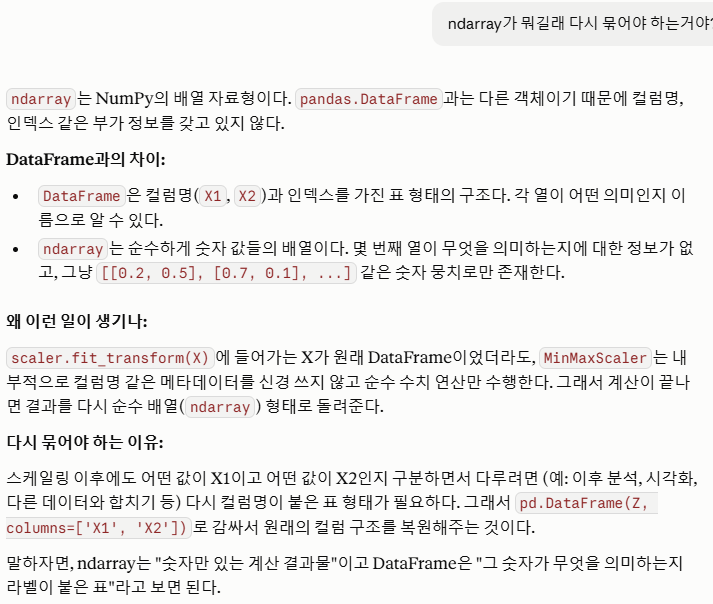

인덱스 : dataframe의 행(가로줄)
컬럼 : dataframe의 열(세로줄)

In [ ]:
# 표준 정규분포에 따라서 데이터의 수준을 맞춤
# 표준 정규분포 : 
from sklearn.preprocessing import StandardScaler # sklearn의 preprocessing 안에 있는 걸 부름

In [9]:
ss_scaler = StandardScaler() # 인스턴스화
Z = ss_scaler.fit_transform(X) # fit_transform => ndarray
pd.DataFrame(Z, columns=['X1', 'X2'])

,X1,X2
0,-1.414214,-1.414214
1,-0.707107,-0.707107
2,0.000000,0.000000
3,0.707107,0.707107
4,1.414214,1.414214


In [18]:
# Standard scaling
from sklearn.preprocessing import StandardScaler

ss_scaler = StandardScaler() # 인스턴스화
S = ss_scaler.fit_transform(X) # fit_transform => ndarray
pd.DataFrame(S, columns=['X1', 'X2'])

,X1,X2
0,-1.414214,-1.414214
1,-0.707107,-0.707107
2,0.000000,0.000000
3,0.707107,0.707107
4,1.414214,1.414214


#### 범위와 사분위 범위 계산 
- 정규분포(np.random.normal)로 부터 무작위 샘플 만들기
- np.random.normal(0,1,1000) # [정규분포] 평균 0, 표준편차 1, 개수 1000개

In [19]:
# np.random.normal(평균, 편차, size = 갯수)
x = np.random.normal(100, 20, size = 1000)
x

array([ 65.80841013, 134.45880196, 114.32649421,  97.35243198,
       103.20334665, 118.77908396, 100.49717347,  66.96740321,
        94.15551651, 126.43035416,  99.68072057, 146.84386524,
       106.36062852, 138.30791705, 134.8030677 , 113.63766142,
       103.91827062,  80.04253947, 125.45210725, 103.14799756,
        75.75288149, 118.63032475,  89.4058654 , 122.43515343,
       109.53595943,  49.99402673,  84.87052749,  84.35895774,
        95.35204387,  93.64026265,  96.95746829,  88.39511006,
        90.55940088,  94.83307698,  82.26448453,  99.44230446,
        83.68751395,  94.05159772, 111.38810926, 116.10248398,
        95.61615174,  88.17840108, 127.31965801, 146.28536671,
        94.73276239,  78.47897835,  93.02174421, 116.34701616,
        78.40743642, 121.1061967 ,  69.03010007, 141.07471273,
        87.49285832, 128.92542703,  54.85484594,  68.10560828,
       116.52357213,  99.94121554, 121.82285007,  72.88224187,
        94.84382574,  76.09145108, 115.02941114, 125.19

In [20]:
print(np.ptp(x))
print(np.max(x) - np.min(x))

123.93614772187573
123.93614772187573


In [21]:
print(np.quantile(x, 0.75) - np.quantile(x, 0.25))
print(stats.iqr(x))

26.10191402988478
26.101914029884767


In [18]:
# 같은 내용을 판다스로 만든다면
x = pd.Series(np.random.normal(100, 20, size = 1000))
x

0       57.851272
1       60.816117
2      125.658849
3       98.223376
4       54.036977
          ...    
995     74.455622
996    104.990764
997    106.918877
998     81.665793
999    105.169047
Length: 1000, dtype: float64